# Final Pipeline Notebook

This notebook presents the complete end-to-end pipeline for the Chicago crime classification project. It summarises the main workflow developed across the CRISP-DM phases, including data loading, cleaning, feature engineering, modelling, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_SEED = 42


## Step 1: Load Dataset
The primary Chicago crime dataset is loaded and restricted to 50,000 rows for efficiency.


In [2]:
df = pd.read_csv("Chicago_Crimes_2012_to_2017.csv", nrows=50000)
df.head()


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,3,10508693,HZ250496,05/03/2016 11:40:00 PM,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)"
1,89,10508695,HZ250409,05/03/2016 09:40:00 PM,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)"
2,197,10508697,HZ250503,05/03/2016 11:31:00 PM,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)"
3,673,10508698,HZ250424,05/03/2016 10:10:00 PM,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)"
4,911,10508699,HZ250455,05/03/2016 10:00:00 PM,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)"


## Step 2: Audit and Inspect Data
A quick audit is performed to understand the structure, missing values, and types of the dataset before cleaning.


In [3]:
print("Shape:", df.shape)
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())


Shape: (50000, 23)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            50000 non-null  int64  
 1   ID                    50000 non-null  int64  
 2   Case Number           50000 non-null  str    
 3   Date                  50000 non-null  str    
 4   Block                 50000 non-null  str    
 5   IUCR                  50000 non-null  str    
 6   Primary Type          50000 non-null  str    
 7   Description           50000 non-null  str    
 8   Location Description  49918 non-null  str    
 9   Arrest                50000 non-null  bool   
 10  Domestic              50000 non-null  bool   
 11  Beat                  50000 non-null  int64  
 12  District              50000 non-null  float64
 13  Ward                  49999 non-null  float64
 14  Community Area        49985 non-null  float64
 15  FBI Code   

## Step 3: Clean Data
Relevant variables are selected and missing values in key fields are handled.


In [4]:
selected_columns = [
    "Primary Type",
    "District",
    "Beat",
    "Ward",
    "Community Area",
    "Latitude",
    "Longitude",
    "Date",
    "Arrest",
    "Domestic"
]

df = df[selected_columns].copy()

df["Community Area"] = df["Community Area"].fillna(df["Community Area"].median())
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())
df["Ward"] = df["Ward"].fillna(df["Ward"].median())

df = df.drop_duplicates()
df.head()


,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Date,Arrest,Domestic
0,BATTERY,10.0,1022,24.0,29.0,41.864073,-87.706819,05/03/2016 11:40:00 PM,True,True
1,BATTERY,3.0,313,20.0,42.0,41.782922,-87.604363,05/03/2016 09:40:00 PM,False,True
2,PUBLIC PEACE VIOLATION,15.0,1524,37.0,25.0,41.894908,-87.758372,05/03/2016 11:31:00 PM,False,False
3,BATTERY,15.0,1532,28.0,25.0,41.885687,-87.749516,05/03/2016 10:10:00 PM,False,False
4,THEFT,15.0,1523,28.0,25.0,41.886297,-87.761751,05/03/2016 10:00:00 PM,False,True


## Step 4: Feature Engineering
Date-based features are extracted to improve predictive performance.


In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
df["Hour"] = df["Date"].dt.hour
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

df = df.drop(columns=["Date"])
df.head()


,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Arrest,Domestic,Hour,DayOfWeek,Month
0,BATTERY,10.0,1022,24.0,29.0,41.864073,-87.706819,True,True,23,1,5
1,BATTERY,3.0,313,20.0,42.0,41.782922,-87.604363,False,True,21,1,5
2,PUBLIC PEACE VIOLATION,15.0,1524,37.0,25.0,41.894908,-87.758372,False,False,23,1,5
3,BATTERY,15.0,1532,28.0,25.0,41.885687,-87.749516,False,False,22,1,5
4,THEFT,15.0,1523,28.0,25.0,41.886297,-87.761751,False,True,22,1,5


## Step 5: Exploratory Snapshot
A quick visual check is used to inspect the target distribution.


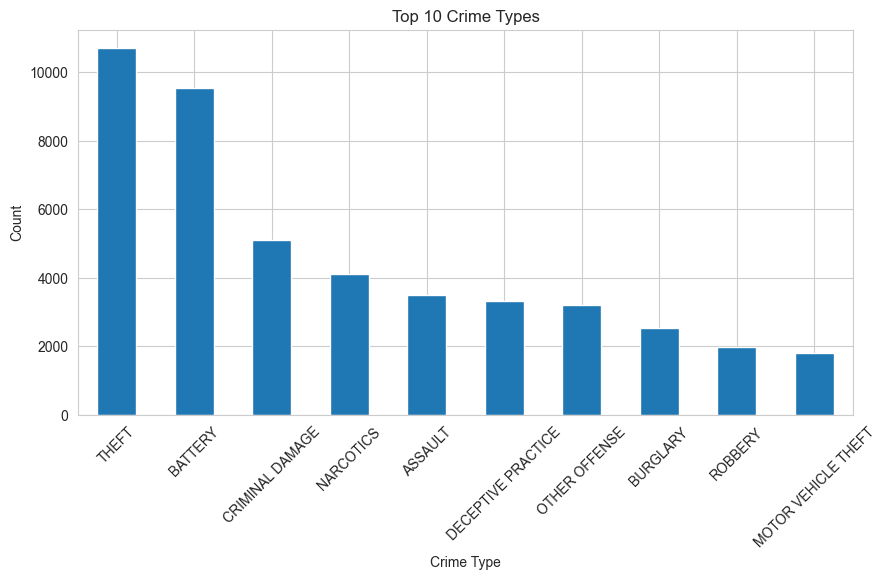

In [6]:
plt.figure(figsize=(10, 5))
df["Primary Type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


## Step 6: Train/Test Split
The data is split into training and testing sets using stratification to preserve class balance.


In [8]:
X = df.drop(columns=["Primary Type"])
y = df["Primary Type"]

# Remove rows where target is missing
valid_mask = y.notna()
X = X[valid_mask]
y = y[valid_mask]

# Drop very rare classes so stratified split can work
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index

mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Number of classes kept:", y.nunique())

Training set: (39913, 11)
Test set: (9979, 11)
Number of classes kept: 30


## Step 7: Train Model
A Random Forest classifier is trained as the selected final model.


In [9]:
rf = RandomForestClassifier(
    random_state=RANDOM_SEED,
    n_estimators=100
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step 8: Hyperparameter Tuning
A small grid search is used to improve model performance.


In [ ]:
param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


C:\Users\meeka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


## Step 9: Evaluate Model
The final tuned model is evaluated using accuracy, precision, recall, and weighted F1-score.


In [ ]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))


In [ ]:
print(classification_report(y_test, y_pred, zero_division=0))


In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Step 10: Cross-Validation
Cross-validation is used to assess whether the model generalises consistently across different folds.


In [ ]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1 scores:", np.round(cv_scores, 4))
print("Mean F1:", round(cv_scores.mean(), 4))
print("Std Dev:", round(cv_scores.std(), 4))


## Final Summary
This notebook provides a compact end-to-end version of the full crime classification workflow. The project uses data cleaning, feature engineering, machine learning, and evaluation to predict crime type from temporal and spatial features. The tuned Random Forest model achieved the best overall performance, although results remain limited by class imbalance and the complexity of the multi-class problem.
